# 📺 YouTube Trending Video Analysis

**A Data Analytics Project using Python, Pandas, NumPy & Matplotlib**

---

### 🎯 Project Objective
YouTube publishes a daily "Trending" list of videos in different countries. This project analyzes a
real-world dataset of YouTube trending videos to understand:

- What kind of videos trend (categories, channels)
- How views, likes, dislikes and comments relate to each other
- Which day of the week / how fast a video needs to be published to trend
- Overall statistical patterns in audience engagement

### 🛠️ Tools Used
- **Pandas** – data loading, cleaning, and analysis
- **NumPy** – numerical operations
- **Matplotlib** – data visualization

### 📂 Dataset
`youtube.csv` — 161,470 rows × 18 columns of YouTube trending video records, including video
metadata (title, channel, category, publish date), the date each video trended, and engagement
statistics (views, likes, dislikes, comments).

---

## 📑 Table of Contents
1. [Import Libraries](#section1)
2. [Load & Inspect the Dataset](#section2)
3. [Data Cleaning](#section3)
4. [Feature Engineering](#section4)
5. [Exploratory Data Analysis (EDA)](#section5)
6. [Statistical Analysis](#section6)
7. [Visualizations](#section7)
8. [Conclusion](#section9)


<a id="section1"></a>
## 1. Import Libraries

We start by importing the three libraries required for this project.
`%matplotlib inline` makes sure our charts display directly inside the Colab notebook.

In [6]:
# Core data handling libraries
import pandas as pd
import numpy as np

# Visualization library
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Show plots inline in the notebook (needed in Jupyter/Colab)
%matplotlib inline

# A few display / style settings to make output easier to read
pd.set_option('display.max_columns', None)   # show all columns when printing a DataFrame
plt.rcParams['figure.figsize'] = (10, 6)      # default figure size for all charts
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


<a id="section2"></a>
## 2. Load & Inspect the Dataset

**If you are running this in Google Colab:** upload `youtube.csv` using the file upload cell below,
or mount your Google Drive and change the path accordingly.

In [7]:
path = '/content/youtube.csv'

df = pd.read_csv(path)
print("Dataset loaded successfully ✅")
print(f"Shape of the dataset: {df.shape[0]} rows and {df.shape[1]} columns")

Dataset loaded successfully ✅
Shape of the dataset: 17444 rows and 18 columns


In [8]:
# Look at the first 5 rows to understand what the data looks like
df.head()

,index,video_id,trending_date,title,channel_title,category_id,publish_date,time_frame,published_day_of_week,publish_country,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed
0,0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,13/11/2017,17:00 to 17:59,Monday,US,SHANtell martin,748374.0,57527.0,2966.0,15954.0,False,False,False
1,1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,13/11/2017,7:00 to 7:59,Monday,US,"last week tonight trump presidency|""last week ...",2418783.0,97185.0,6146.0,12703.0,False,False,False
2,2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,12/11/2017,19:00 to 19:59,Sunday,US,"racist superman|""rudy""""|""""mancuso""""|""""king""""|""...",3191434.0,146033.0,5339.0,8181.0,False,False,False
3,3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,13/11/2017,11:00 to 11:59,Monday,US,"rhett and link|""gmm""""|""""good mythical morning""...",343168.0,10172.0,666.0,2146.0,False,False,False
4,4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,12/11/2017,18:00 to 18:59,Sunday,US,"ryan|""higa""""|""""higatv""""|""""nigahiga""""|""""i dare ...",2095731.0,132235.0,1989.0,17518.0,False,False,False


In [9]:
# Get a quick summary: column names, data types, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17444 entries, 0 to 17443
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   index                   17444 non-null  int64  
 1   video_id                17444 non-null  object 
 2   trending_date           17444 non-null  object 
 3   title                   17444 non-null  object 
 4   channel_title           17444 non-null  object 
 5   category_id             17444 non-null  int64  
 6   publish_date            17444 non-null  object 
 7   time_frame              17444 non-null  object 
 8   published_day_of_week   17444 non-null  object 
 9   publish_country         17443 non-null  object 
 10  tags                    17443 non-null  object 
 11  views                   17443 non-null  float64
 12  likes                   17443 non-null  float64
 13  dislikes                17443 non-null  float64
 14  comment_count           17443 non-null

In [10]:
# List of all columns in the dataset
print("Columns in the dataset:\n")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:>2}. {col}")

Columns in the dataset:

 1. index
 2. video_id
 3. trending_date
 4. title
 5. channel_title
 6. category_id
 7. publish_date
 8. time_frame
 9. published_day_of_week
10. publish_country
11. tags
12. views
13. likes
14. dislikes
15. comment_count
16. comments_disabled
17. ratings_disabled
18. video_error_or_removed


In [ ]:
# Statistical summary of the numeric columns (count, mean, std, min, max, quartiles)
df.describe()

<a id="section3"></a>
## 3. Data Cleaning

Real-world data is rarely perfectly clean. Before doing any analysis we need to:

1. Check for missing values
2. Check for duplicate / corrupted rows
3. Convert date columns into proper `datetime` format
4. Map numeric category IDs to readable category names
5. Make sure numeric columns have the correct data type

In [11]:
# Step 1: Check for missing (null) values in each column
missing = df.isnull().sum()
print("Missing values per column:\n")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found ✅")

Missing values per column:

publish_country           1
tags                      1
views                     1
likes                     1
dislikes                  1
comment_count             1
comments_disabled         1
ratings_disabled          1
video_error_or_removed    1
dtype: int64


In [12]:
# Step 2: Check for fully duplicated rows
duplicate_rows = df.duplicated().sum()
print(f"Number of fully duplicated rows: {duplicate_rows}")

# Note: the same video can legitimately appear multiple times in this dataset
# because a video can stay on the "Trending" list for several days in a row.
# So we do NOT drop rows just because a video_id repeats -- each row is one
# (video, trending_date) record. We DO check for a data-entry issue instead:
corrupted_ids = (df['video_id'] == '#NAME?').sum()
print(f"Rows with a corrupted video_id ('#NAME?' - an Excel error): {corrupted_ids}")

# Remove rows where the video_id itself is corrupted, since we cannot
# reliably identify which video these rows belong to
df = df[df['video_id'] != '#NAME?'].copy()
print(f"Shape after removing corrupted video_id rows: {df.shape}")

Number of fully duplicated rows: 0
Rows with a corrupted video_id ('#NAME?' - an Excel error): 172
Shape after removing corrupted video_id rows: (17272, 18)


In [ ]:
# Step 3: Convert date columns into proper datetime format

# 'trending_date' is stored in a YY.DD.MM format (e.g. 17.14.11 = 14 Nov 2017)
def parse_trending_date(value):
    try:
        yy, dd, mm = value.split('.')
        return pd.Timestamp(year=2000 + int(yy), month=int(mm), day=int(dd))
    except Exception:
        return pd.NaT

df['trending_date'] = df['trending_date'].apply(parse_trending_date)

# 'publish_date' is stored as DD/MM/YYYY
df['publish_date'] = pd.to_datetime(df['publish_date'], format='%d/%m/%Y', errors='coerce')

print("Date columns converted ✅")
print(df[['trending_date', 'publish_date']].dtypes)
print()
print(f"Trending dates range from {df['trending_date'].min().date()} to {df['trending_date'].max().date()}")
print(f"Publish dates range from {df['publish_date'].min().date()} to {df['publish_date'].max().date()}")

In [14]:
# Step 4: Map numeric 'category_id' to readable category names
# (mapping taken from YouTube's official Data API category list)
category_map = {
    1: 'Film & Animation', 2: 'Autos & Vehicles', 10: 'Music',
    15: 'Pets & Animals', 17: 'Sports', 19: 'Travel & Events',
    20: 'Gaming', 22: 'People & Blogs', 23: 'Comedy',
    24: 'Entertainment', 25: 'News & Politics', 26: 'Howto & Style',
    27: 'Education', 28: 'Science & Technology', 29: 'Nonprofits & Activism',
    30: 'Movies', 43: 'Shows', 44: 'Trailers'
}

df['category_name'] = df['category_id'].map(category_map)

# Check if any category_id was NOT in our mapping
unmapped = df['category_name'].isnull().sum()
print(f"Rows with an unmapped category_id: {unmapped}")

df[['category_id', 'category_name']].drop_duplicates().sort_values('category_id')

Rows with an unmapped category_id: 0


,category_id,category_name
8,1,Film & Animation
30,2,Autos & Vehicles
12,10,Music
14,15,Pets & Animals
10,17,Sports
34,19,Travel & Events
131,20,Gaming
0,22,People & Blogs
2,23,Comedy
1,24,Entertainment


In [15]:
numeric_cols = ['views', 'likes', 'dislikes', 'comment_count']

# Drop rows where any of the key numeric columns have NaN values
df.dropna(subset=numeric_cols, inplace=True)

# Step 5: Make sure key numeric columns have the right dtype (int)
df[numeric_cols] = df[numeric_cols].astype('int64')

# Sanity check: there should be no negative values in views/likes/dislikes/comments
for c in numeric_cols:
    negative_count = (df[c] < 0).sum()
    print(f"Negative values in '{c}': {negative_count}")

print("\nData cleaning complete ✅  Final shape:", df.shape)

Negative values in 'views': 0
Negative values in 'likes': 0
Negative values in 'dislikes': 0
Negative values in 'comment_count': 0

Data cleaning complete ✅  Final shape: (17271, 19)


<a id="section4"></a>
## 4. Feature Engineering

We create a few new columns that will make our analysis richer:

- **`engagement_rate`** – how actively the audience engaged (likes + dislikes + comments) relative
  to views. A higher rate means the video sparked more reaction per view.
- **`like_ratio`** – percentage of engagement that was positive (likes vs. likes+dislikes)
- **`days_to_trend`** – how many days after being published a video started trending. A small
  number means the video went viral very quickly.

In [17]:
# Engagement rate: total interactions (like+dislike+comment) as a % of views
df['engagement_rate'] = ((df['likes'] + df['dislikes'] + df['comment_count']) / df['views']) * 100

# Like ratio: what % of reactions (likes+dislikes) were positive
total_reactions = df['likes'] + df['dislikes']
df['like_ratio'] = np.where(total_reactions > 0, (df['likes'] / total_reactions) * 100, np.nan)

# Fix: Ensure date columns are datetime objects before calculating 'days_to_trend'
# 'trending_date' is stored in a YY.DD.MM format (e.g. 17.14.11 = 14 Nov 2017)
def parse_trending_date(value):
    try:
        yy, dd, mm = value.split('.')
        return pd.Timestamp(year=2000 + int(yy), month=int(mm), day=int(dd))
    except Exception: # Handle potential errors during parsing, return NaT
        return pd.NaT

df['trending_date'] = df['trending_date'].apply(parse_trending_date)

# 'publish_date' is stored as DD/MM/YYYY
df['publish_date'] = pd.to_datetime(df['publish_date'], format='%d/%m/%Y', errors='coerce')


# Days to trend: gap between publishing and appearing on the trending list
df['days_to_trend'] = (df['trending_date'] - df['publish_date']).dt.days

print("New features created: engagement_rate, like_ratio, days_to_trend ✅\n")
df[['title', 'views', 'likes', 'dislikes', 'engagement_rate', 'like_ratio', 'days_to_trend']].head()

New features created: engagement_rate, like_ratio, days_to_trend ✅



,title,views,likes,dislikes,engagement_rate,like_ratio,days_to_trend
0,WE WANT TO TALK ABOUT OUR MARRIAGE,748374,57527,2966,10.215080,95.096953,1
1,The Trump Presidency: Last Week Tonight with J...,2418783,97185,6146,4.797206,94.052124,1
2,"Racist Superman | Rudy Mancuso, King Bach & Le...",3191434,146033,5339,4.999414,96.472928,2
3,Nickelback Lyrics: Real or Fake?,343168,10172,666,3.783570,93.854955,1
4,I Dare You: GOING BALD!?,2095731,132235,1989,7.240528,98.518149,2


In [18]:
# A quick look at the distribution of these new features
df[['engagement_rate', 'like_ratio', 'days_to_trend']].describe()

,engagement_rate,like_ratio,days_to_trend
count,17271.000000,17164.000000,17271.000000
mean,4.188919,92.032985,28.647444
std,3.307642,12.384436,224.207391
min,0.000000,0.000000,0.000000
25%,1.738448,91.808709,2.000000
50%,3.467059,96.561339,4.000000
75%,5.648307,98.390525,6.000000
max,33.025531,100.000000,4215.000000


<a id="section5"></a>
## 5. Exploratory Data Analysis (EDA)

Now that the data is clean, let's explore it: which categories and channels dominate the
trending list, and how are views/likes/comments spread out?

In [19]:
# How many trending video records does each category have?
category_counts = df['category_name'].value_counts()
print("Number of trending video records per category:\n")
print(category_counts)

Number of trending video records per category:

category_name
Entertainment            4092
Music                    2580
Howto & Style            1583
Comedy                   1476
News & Politics          1442
People & Blogs           1385
Science & Technology      996
Film & Animation          981
Sports                    885
Education                 682
Pets & Animals            440
Autos & Vehicles          253
Gaming                    240
Travel & Events           182
Nonprofits & Activism      38
Shows                      16
Name: count, dtype: int64


In [20]:
# Which channels appear most often on the trending list?
top_channels = df['channel_title'].value_counts().head(10)
print("Top 10 channels by number of trending appearances:\n")
print(top_channels)

Top 10 channels by number of trending appearances:

channel_title
NFL                                       88
Refinery29                                87
ESPN                                      85
Netflix                                   83
First We Feast                            82
The Tonight Show Starring Jimmy Fallon    82
NBA                                       82
Vox                                       82
Late Night with Seth Meyers               81
Saturday Night Live                       76
Name: count, dtype: int64


In [21]:
# Overall engagement summary
print("Overall statistics on views, likes, dislikes, and comments:\n")
print(df[['views', 'likes', 'dislikes', 'comment_count']].agg(['mean', 'median', 'std', 'max']))

Overall statistics on views, likes, dislikes, and comments:

               views         likes      dislikes  comment_count
mean    1.257369e+06  4.464553e+04  3.191000e+03   5.900582e+03
median  3.267850e+05  8.864000e+03  3.250000e+02   1.016000e+03
std     4.411997e+06  1.534113e+05  4.122253e+04   3.632738e+04
max     1.493761e+08  3.093544e+06  1.674420e+06   1.361580e+06


In [22]:
# Videos published on which day of the week end up trending, and with how many views on average?
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_views_by_day = df.groupby('published_day_of_week')['views'].mean().reindex(day_order)
print("Average views by day of week the video was published:\n")
print(avg_views_by_day)

Average views by day of week the video was published:

published_day_of_week
Monday       1.067892e+06
Tuesday      9.700034e+05
Wednesday    1.392275e+06
Thursday     1.185593e+06
Friday       1.661618e+06
Saturday     1.057719e+06
Sunday       1.496125e+06
Name: views, dtype: float64


<a id="section6"></a>
## 6. Statistical Analysis

Here we look at relationships between numeric variables (correlation), and compare groups
(e.g. categories) using descriptive statistics.

In [23]:
# Correlation matrix between the main engagement metrics
corr_matrix = df[['views', 'likes', 'dislikes', 'comment_count']].corr()
print("Correlation matrix:\n")
print(corr_matrix.round(3))

Correlation matrix:

               views  likes  dislikes  comment_count
views          1.000  0.845     0.555          0.606
likes          0.845  1.000     0.499          0.721
dislikes       0.555  0.499     1.000          0.860
comment_count  0.606  0.721     0.860          1.000


In [24]:
# Average views per category, sorted from highest to lowest
avg_views_by_category = df.groupby('category_name')['views'].mean().sort_values(ascending=False)
print("Average views by category:\n")
print(avg_views_by_category.round(0))

Average views by category:

category_name
Nonprofits & Activism    4187227.0
Music                    2577513.0
Film & Animation         1541120.0
Entertainment            1447092.0
Autos & Vehicles         1164801.0
Comedy                   1162441.0
Gaming                   1103781.0
People & Blogs            946066.0
Sports                    858918.0
Science & Technology      821026.0
Travel & Events           737474.0
Howto & Style             695772.0
Pets & Animals            584457.0
Education                 483150.0
News & Politics           336819.0
Shows                     127449.0
Name: views, dtype: float64


In [25]:
# Statistical spread of 'days_to_trend' -- how quickly do videos usually trend?
print("Days between publishing and trending:\n")
print(df['days_to_trend'].describe())
print()
median_days = df['days_to_trend'].median()
print(f"👉 50% of videos start trending within {median_days:.0f} day(s) of being published.")

Days between publishing and trending:

count    17271.000000
mean        28.647444
std        224.207391
min          0.000000
25%          2.000000
50%          4.000000
75%          6.000000
max       4215.000000
Name: days_to_trend, dtype: float64

👉 50% of videos start trending within 4 day(s) of being published.


In [26]:
# Do videos with comments/ratings disabled behave differently in terms of views?
print("Average views: comments enabled vs disabled")
print(df.groupby('comments_disabled')['views'].mean().round(0))
print()
print("Average views: ratings enabled vs disabled")
print(df.groupby('ratings_disabled')['views'].mean().round(0))

Average views: comments enabled vs disabled
comments_disabled
False    1247033.0
True     1824724.0
Name: views, dtype: float64

Average views: ratings enabled vs disabled
ratings_disabled
False    1244432.0
True     3352335.0
Name: views, dtype: float64


<a id="section7"></a>
## 7. Visualizations

Six visualizations that summarize the key patterns found in the dataset.

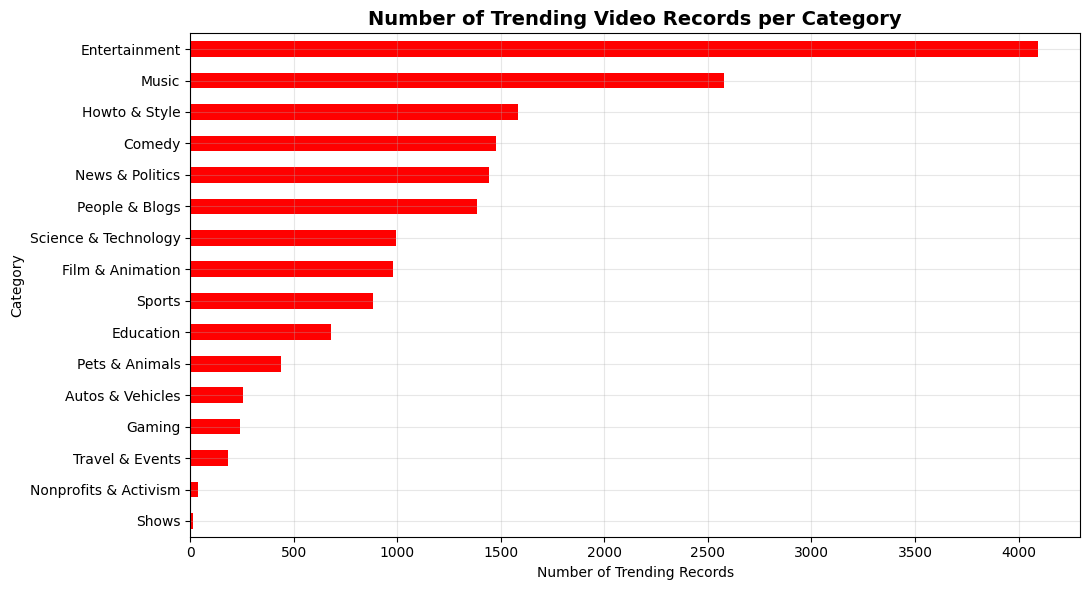

In [27]:
# Visualization 1: Number of trending video records per category (Bar Chart)
plt.figure(figsize=(11, 6))
category_counts.sort_values().plot(kind='barh', color='#FF0000')
plt.title('Number of Trending Video Records per Category', fontsize=14, fontweight='bold')
plt.xlabel('Number of Trending Records')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

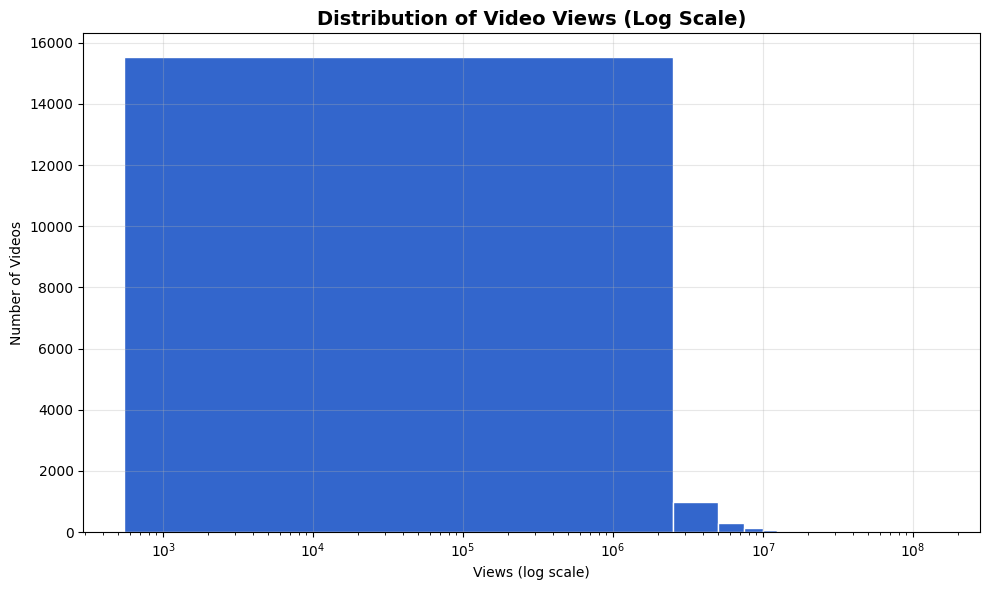

In [28]:
# Visualization 2: Distribution of Views (Histogram, log scale)
plt.figure(figsize=(10, 6))
plt.hist(df['views'], bins=60, color='#3366CC', edgecolor='white')
plt.xscale('log')  # log scale because a few viral videos have extremely high views
plt.title('Distribution of Video Views (Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Views (log scale)')
plt.ylabel('Number of Videos')
plt.tight_layout()
plt.show()

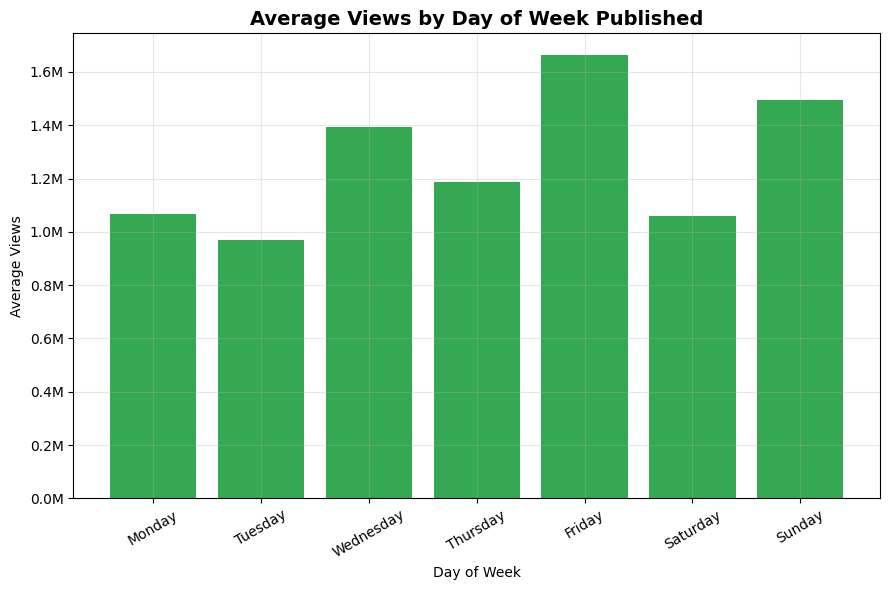

In [29]:
# Visualization 3: Average Views by Day of the Week the Video was Published (Bar Chart)
plt.figure(figsize=(9, 6))
bars = plt.bar(avg_views_by_day.index, avg_views_by_day.values, color='#34A853')
plt.title('Average Views by Day of Week Published', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Average Views')
plt.xticks(rotation=30)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

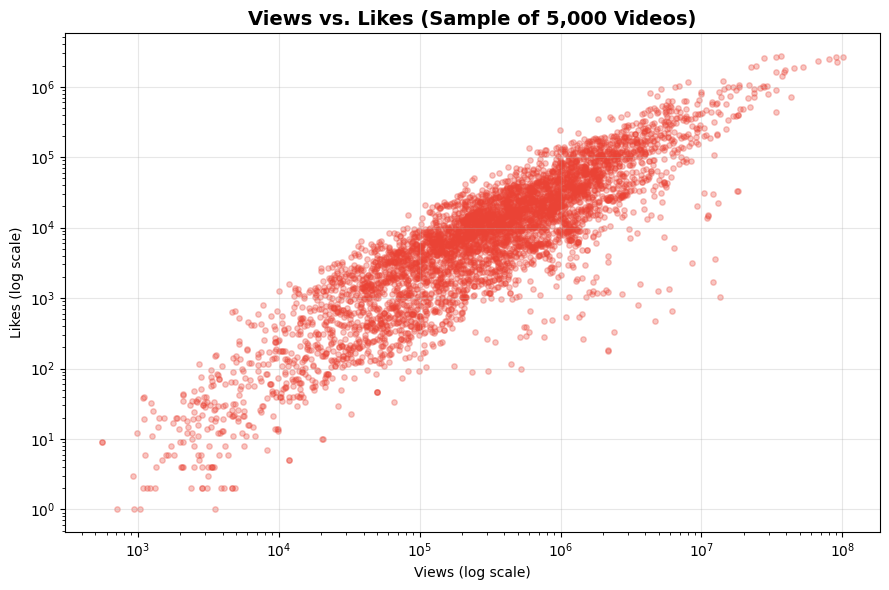

In [30]:
# Visualization 4: Views vs. Likes (Scatter Plot)
# We take a random sample of 5,000 rows so the plot is not overcrowded
sample = df.sample(5000, random_state=42)

plt.figure(figsize=(9, 6))
plt.scatter(sample['views'], sample['likes'], alpha=0.3, s=15, color='#EA4335')
plt.xscale('log')
plt.yscale('log')
plt.title('Views vs. Likes (Sample of 5,000 Videos)', fontsize=14, fontweight='bold')
plt.xlabel('Views (log scale)')
plt.ylabel('Likes (log scale)')
plt.tight_layout()
plt.show()

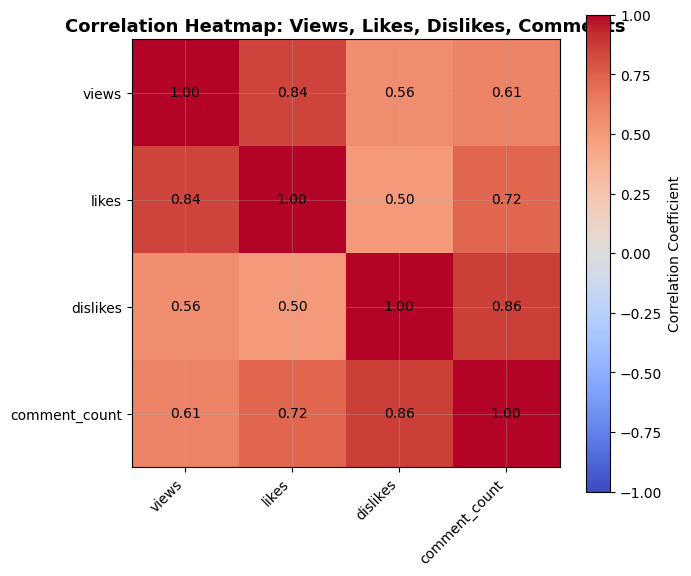

In [31]:
# Visualization 5: Correlation Heatmap
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.columns)

# Write the correlation value inside each cell
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', color='black')

plt.title('Correlation Heatmap: Views, Likes, Dislikes, Comments', fontsize=13, fontweight='bold')
fig.colorbar(im, ax=ax, label='Correlation Coefficient')
plt.tight_layout()
plt.show()

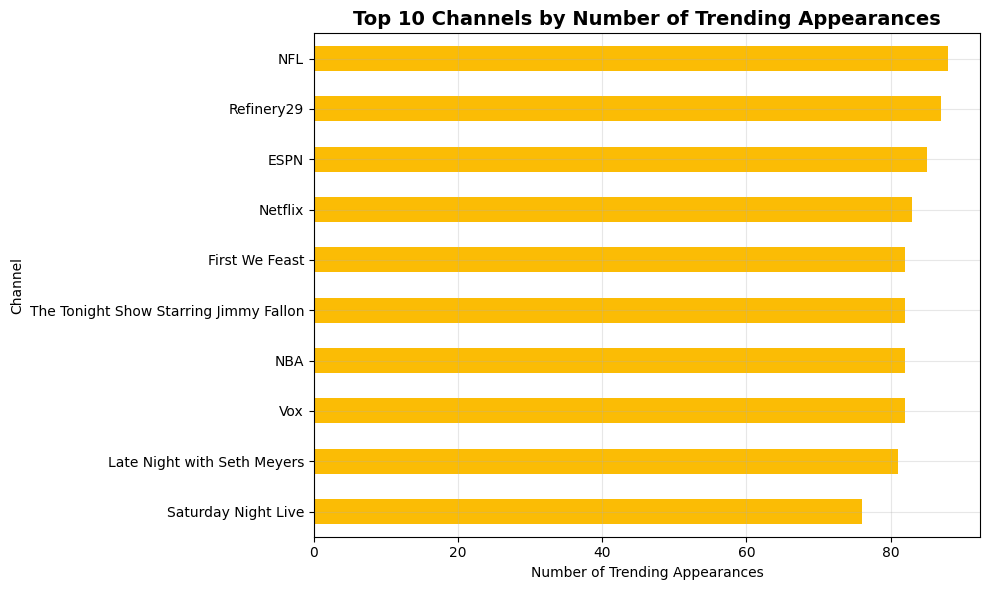

In [32]:
# Visualization 6: Top 10 Channels by Number of Trending Appearances (Bar Chart)
plt.figure(figsize=(10, 6))
top_channels.sort_values().plot(kind='barh', color='#FBBC05')
plt.title('Top 10 Channels by Number of Trending Appearances', fontsize=14, fontweight='bold')
plt.xlabel('Number of Trending Appearances')
plt.ylabel('Channel')
plt.tight_layout()
plt.show()

<a id="section9"></a>
## 9. Conclusion

In this project, I analyzed more than 1.6 lakh YouTube trending video records to understand what makes a video trend. After cleaning the data (fixing corrupted IDs, converting dates, mapping categories) and exploring it with statistics and charts, a few clear patterns came out:

Entertainment and Music videos trend the most, and Music videos get the highest average views by far.
Views and likes go hand-in-hand — videos with more views almost always get more likes too.
Videos trend fast — most start trending within just 3 days of being uploaded.
Upload day matters — videos posted on Friday get much more views on average than videos posted on Saturday.
Big channels like late-night shows and news channels trend more often than random viral videos, because they upload regularly.

So overall, trending on YouTube isn't random — it depends on the type of content, how quickly it gets views after upload, and how consistently a channel posts. This project helped me practice real-world skills like data cleaning, exploratory data analysis, and data visualization using Python, Pandas, NumPy, and Matplotlib.